## Lab # 03: Logistic Regression


### **Student Information**
- **Name**: Abdul Hayy Khan
- **Roll No**: 24F-AI-051

#### Tasks:

- Import Required Libraries
- Load Dataset
  - Use a dataset Breast Cancer Dataset from sklearn.datasets.
- Exploratory Data Analysis (EDA)
  - Display first few rows of the dataset.
  - Check for missing values.
  - Plot histograms or distribution of features.
  - Check class distribution (malignant vs. benign).
- Data Preprocessing
  - Split features and labels.
  - Standardize features using StandardScaler.
  - Train-test split.
- Model Implementation
  - Use sklearn.linear_model.LogisticRegression.
  - Train the model on the training data.
  - Predict on the test data.
- Evaluation
  - Accuracy score.
  - Confusion matrix.
  - Precision, Recall, F1-score

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
# Load dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

In [ ]:
# Display first few rows and check missing values
display(X.head())
print("Missing values:", X.isnull().sum().sum())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Missing values: 0


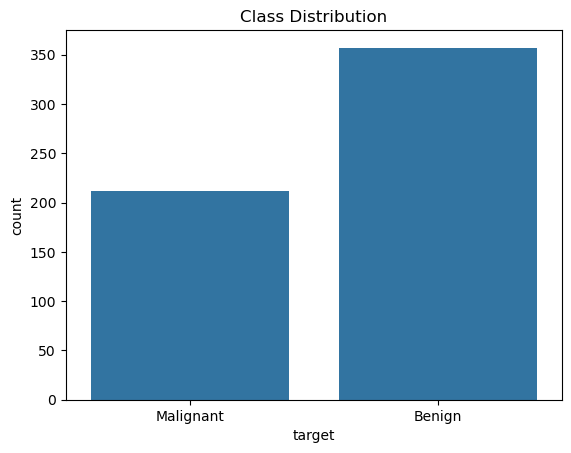

In [6]:
# Class distribution
sns.countplot(x=y.map({0: "Malignant", 1: "Benign"}))
plt.title("Class Distribution")
plt.show()

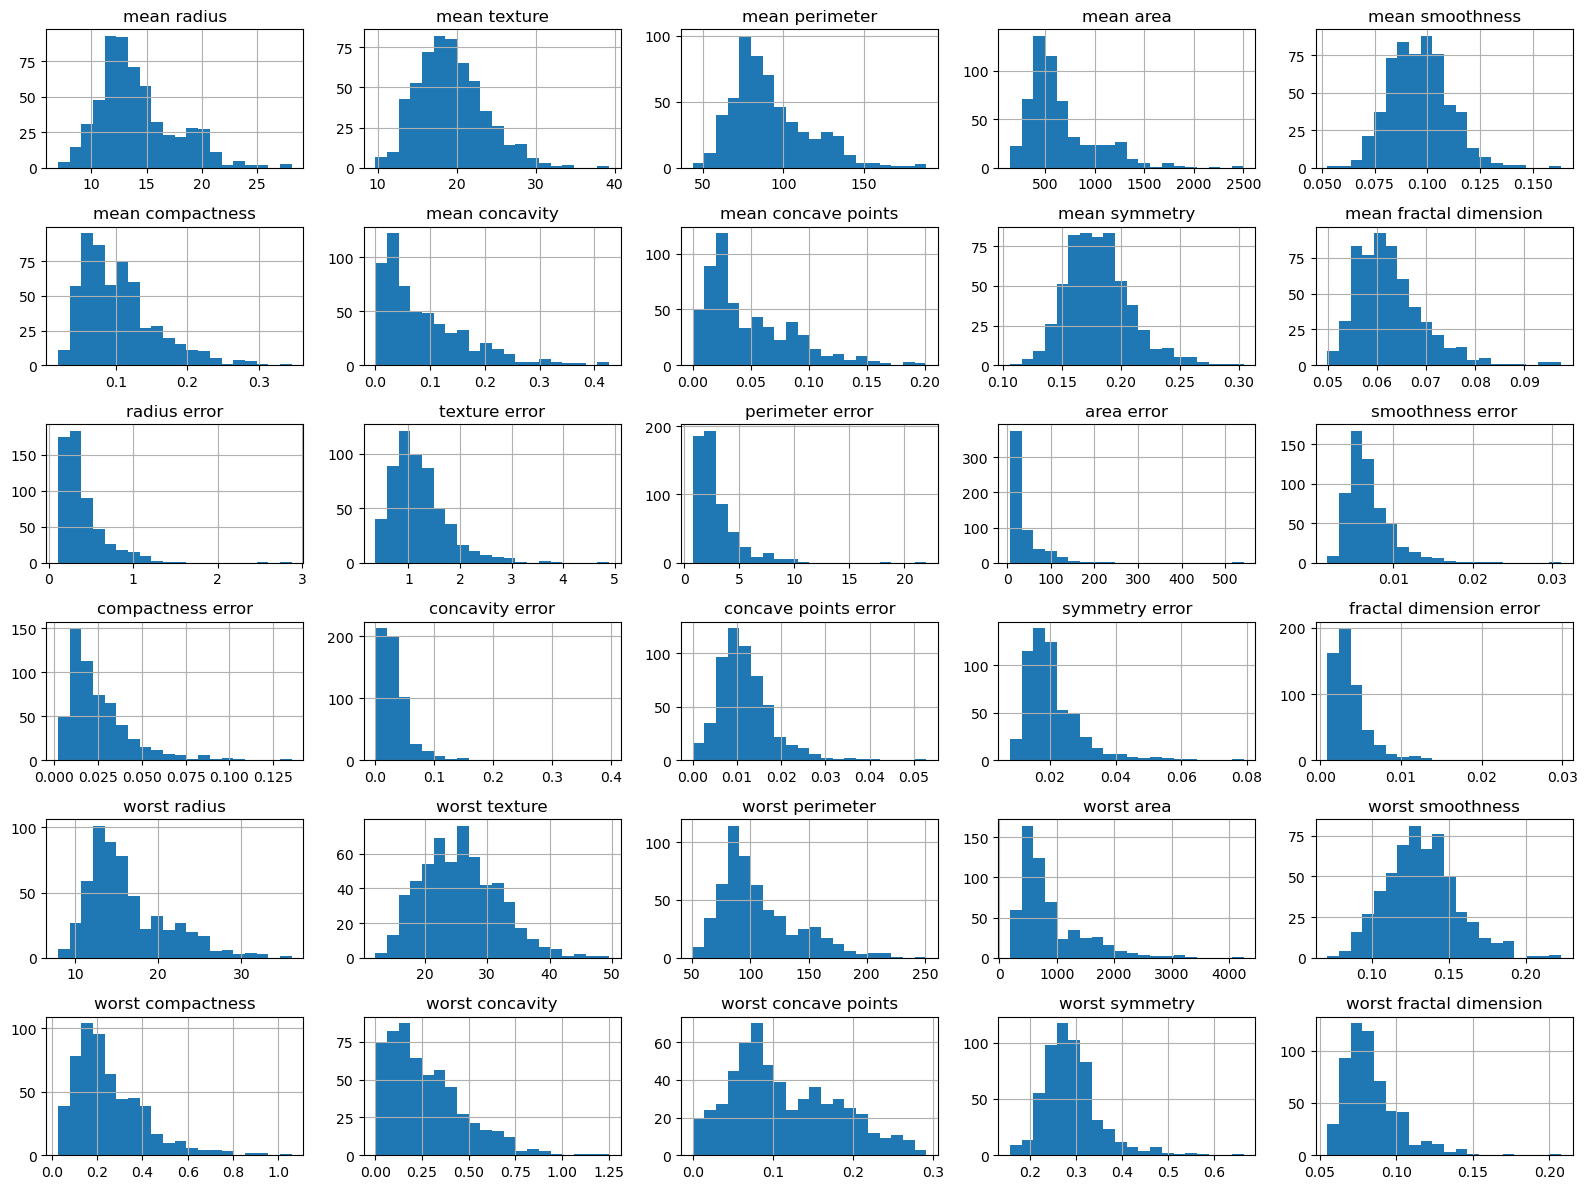

In [7]:
# Feature distributions
X.hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.show()

In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Train logistic regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [11]:
# Predictions
y_pred = model.predict(X_test_scaled)

In [12]:
# Evaluation
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Malignant", "Benign"]
))

Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



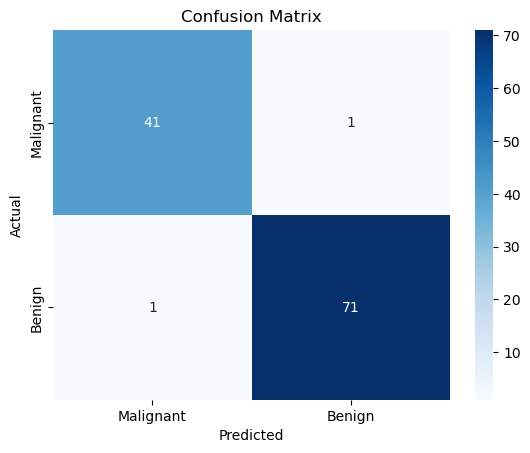

In [14]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()